In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#PCA

In [2]:
# Fijamos la "semilla" del generador aleatorio. Permite reproducibilidad
np.random.seed(42)
n=200

#Generar un array de 200 numeros (que sigan una distribución nomal con media 40.000 y desviación típica 10.000)
ingresos = np.random.normal(40000,10000,n)
datos = {
    "ingresos": ingresos,
    "gasto_super": ingresos * 0.05 + np.random.normal(0,500,n),
    "gasto_restaurante": ingresos*0.03 + np.random.normal(0,300,n),
    "gasto_ocio": ingresos * 0.02 + np.random.normal(0,200,n),
    "gasto_ropa": ingresos * 0.04 + np.random.normal(0,400,n),
    "edad": np.random.normal(40,10,n)
}
df= pd.DataFrame(datos)
df

,ingresos,gasto_super,gasto_restaurante,gasto_ocio,gasto_ropa,edad
0,44967.141530,2427.250757,870.685948,1050.740554,2173.999184,53.993554
1,38617.356988,2211.260113,978.708203,587.914075,1338.276388,49.246337
2,46476.885381,2865.369891,1395.879671,1103.458892,1897.523726,40.596304
3,55230.298564,3288.415954,1671.003135,1375.733543,2024.301827,33.530632
4,37658.466253,1194.088629,994.734346,835.856306,1332.540159,46.982233
...,...,...,...,...,...,...
195,43853.173797,1958.070864,1162.590294,1087.694047,1641.686835,44.404747
196,31161.425638,701.504017,853.880289,615.317482,1965.531636,39.803622
197,41537.251059,2753.798740,952.488417,967.045161,1917.827187,45.524900
198,40582.087184,1971.834437,1084.174638,817.305419,1394.811891,42.239141


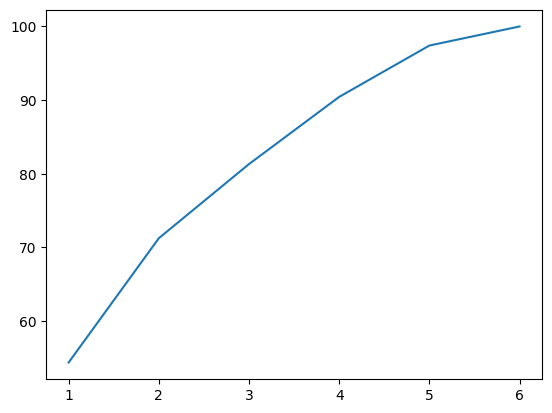

In [3]:
# 1º Paso del PCA: escalar
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# 2º paso: Aplciar PCA sin límite de componentes para ver cuanta varianza explica cada componente
pca_explorador = PCA()  #Sin n_components
pca_explorador.fit(df_scaled)

# 3º paso: Grafico de varianza explicada acumulada por cada principal componente
varianza_acumulada = np.cumsum(pca_explorador.explained_variance_ratio_)
plt.plot(range(1,len(varianza_acumulada)+1), varianza_acumulada * 100)

In [5]:
# Con el gráfico dibujado, decidimos usar 5 componentes principales
pca_final = PCA(n_components=5)
df_pca= pca_final.fit_transform(df_scaled)
df_pca=pd.DataFrame(df_pca, columns=['CP1', 'CP2', 'CP3', 'CP4', 'CP5'])
df_pca

,CP1,CP2,CP3,CP4,CP5
0,0.984727,1.505553,-0.001849,-1.148437,0.292031
1,-0.757923,0.621017,0.862807,-0.018477,-0.074094
2,1.841040,-0.002232,0.350827,-0.084823,0.420308
3,3.454051,-0.640707,0.314964,0.036287,0.831047
4,-0.996167,0.523048,-0.656618,0.153777,0.565360
...,...,...,...,...,...
195,0.647038,0.370376,-0.371843,-0.097606,0.798395
196,-1.585150,0.083200,-1.570859,-0.504919,-0.729943
197,0.788475,0.542943,0.504885,-0.908391,0.284820
198,-0.224471,0.024666,0.148328,0.019083,0.384078


# Visualización de datos

## Matplotlib

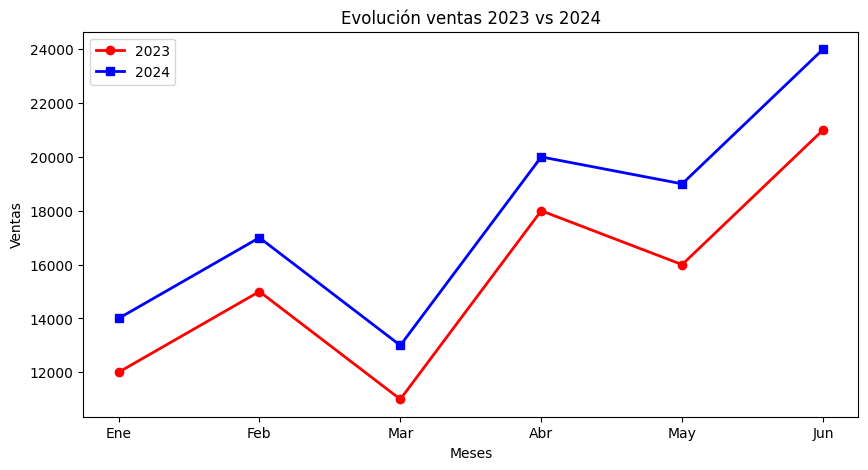

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Grafico 1: Grafico lineal
meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun"]
ventas_2023=[12000,15000,11000,18000,16000,21000]
ventas_2024=[14000,17000,13000,20000,19000, 24000]

fig,ax = plt.subplots(figsize=(10,5))
#Describir lo que va dentro del dibujo
ax.plot(meses, ventas_2023, marker='o', label='2023', color='red', linewidth=2)
ax.plot(meses, ventas_2024, marker='s', label='2024', color='blue', linewidth=2)
#Ponemos titulo
ax.set_title("Evolución ventas 2023 vs 2024")
ax.set_xlabel("Meses")
ax.set_ylabel("Ventas")
ax.legend()
plt.show()

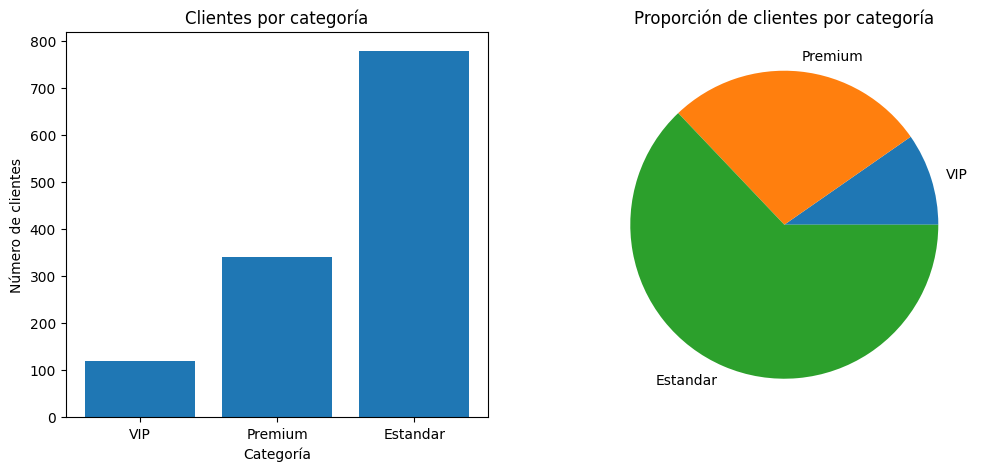

In [7]:
# Grafico 2: Grafico con multiples vistas
fig, (ax1, ax2)= plt.subplots(1,2, figsize=(12,5))

#Grafico izquierda: Barras
categorias=["VIP", "Premium", "Estandar"]
clientes = [120,340,780]
ax1.bar(categorias, clientes)
ax1.set_title("Clientes por categoría")
ax1.set_xlabel("Categoría")
ax1.set_ylabel("Número de clientes")

#Grafico derecho: tarta
ax2.pie(clientes, labels=categorias)
ax2.set_title("Proporción de clientes por categoría")
plt.show()


# Seaborn

In [8]:
import seaborn as sns

#Cargamos dataset que viene por defecto en seaborn
df_tips=sns.load_dataset("tips")
df_tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='day', ylabel='total_bill'>

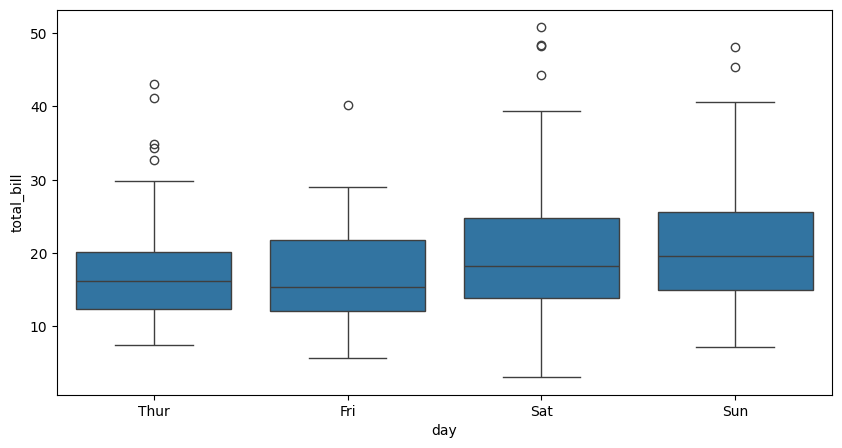

In [9]:
# Grafico 1: Boxplot
plt.figure(figsize=(10,5))
sns.boxplot(x="day", y="total_bill", data=df_tips)

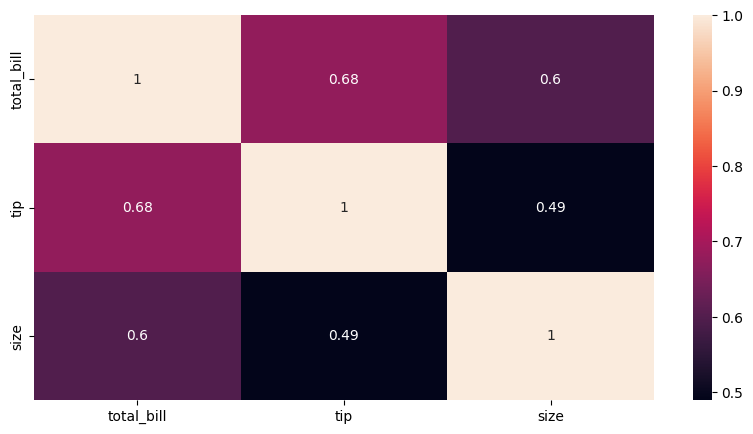

In [10]:
# Grafico 2: Heatmap de correlacion
df_num=df_tips[["total_bill", "tip", "size"]]
plt.figure(figsize=(10,5))
sns.heatmap(df_num.corr(), annot=True)
plt.show()

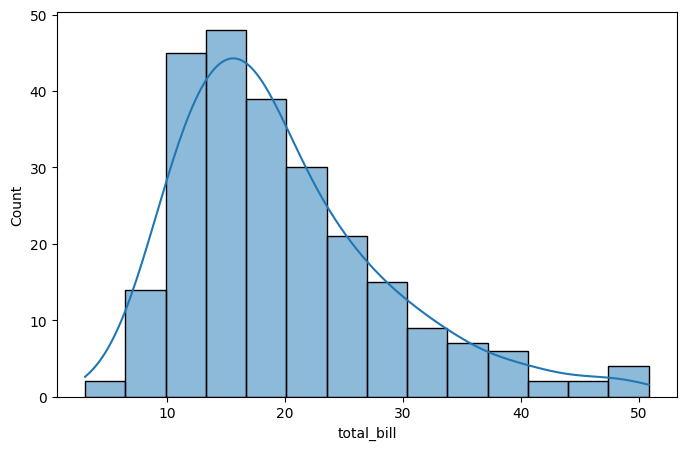

In [11]:
# Grafico 2: Histograma con curva de densidad
plt.figure(figsize=(8,5))
sns.histplot(df_tips["total_bill"], kde=True)
plt.show()

# Plotly

In [12]:
import plotly.express as px  # La forma mas sencilla y rapida de usar Plotly
import pandas as pd

# Cargamos el dataset de ejemplo de Plotly
df_gapminder = px.data.gapminder()
df_2007 = df_gapminder[df_gapminder['year'] == 2007]

# === GRAFICO 1: Scatter interactivo ===
# Igual que el regplot de Seaborn pero INTERACTIVO
fig = px.scatter(
    df_2007,
    x='gdpPercap',
    y='lifeExp',
    color='continent',      # Color por continente
    size='pop',             # Tamano del punto proporcional a la poblacion
    hover_name='country',   # Al pasar el raton aparece el nombre del pais
    log_x=True,             # Escala logaritmica en el eje X
    title='Esperanza de Vida vs PIB per Capita (2007)'
)
fig.show()


In [13]:

# === GRAFICO 2: Barras interactivas con nuestro dataset AWcustomers ===

# Vamos a crearlo desde cero para que todos podais ejecutarlo:
datos_ventas = {
    'Pais': ['Australia', 'United States', 'Canada', 'Germany', 'United Kingdom', 'France'],
    'Ventas_Millones': [15.2, 28.7, 12.1, 9.8, 11.3, 8.5],
    'Clientes': [1200, 2800, 980, 750, 890, 620]
}
df_ventas = pd.DataFrame(datos_ventas)

fig2 = px.bar(
    df_ventas.sort_values('Ventas_Millones', ascending=True),
    x='Ventas_Millones',
    y='Pais',
    orientation='h',
    color='Ventas_Millones',
    color_continuous_scale='Blues',
    text='Ventas_Millones',   # Muestra el valor encima de cada barra
    title='Ventas por Pais (Millones EUR)'
)
fig2.update_traces(texttemplate='%{text:.1f}M', textposition='outside')
fig2.show()



In [14]:

# === GRAFICO 3: Mapa de calor geografico ===
# El grafico mas 'wow' de la sesion
fig3 = px.choropleth(
    df_ventas,
    locations='Pais',
    locationmode='country names',
    color='Ventas_Millones',
    color_continuous_scale='Blues',
    title='Mapa de Ventas Globales'
)
fig3.show()